# Haul anatomy — what drives a double-digit return
_Conditional on a haul (`total_points > 10`), which scoring components delivered the points, by position. DGW excluded — a DGW haul is two fixtures, so excluding it isolates the genuine single-match ceiling._

**Sections:** (a) what a haul is made of · (b) the haul mix, share by component

---

## Setup
> Whole season, `minutes > 0`, **DGW excluded**; reuse the per-component point contributions and keep only haul rows (`total_points > 10`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from domain.fpl_scoring import decompose_total_points

POSITIONS = ["GK", "DEF", "MID", "FWD"]
HAUL_THRESHOLD = 10  # total_points > 10 is a haul

try:
    _r = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _r = load_mart()

mart = _r.mart
df = mart[mart["gw"].between(1, _r.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()
pos = df["position"]

COMP_ORDER = ["appearance", "goals", "assists", "clean_sheets", "saves", "penalties_saved",
              "bonus", "defensive_contribution", "goals_conceded", "cards", "own_goals", "penalties_missed"]
_event_cols = ["goals_scored", "assists", "clean_sheets", "goals_conceded", "saves",
               "penalties_saved", "bonus", "yellow_cards", "red_cards", "own_goals",
               "penalties_missed", "defensive_contribution"]
# Per-component point contributions via the domain formula (single source of truth).
components = pd.DataFrame(
    [decompose_total_points(position=p, minutes=int(m), **{c: int(v) for c, v in row.items()})
     for p, m, row in zip(df["position"], df["minutes"], df[_event_cols].to_dict("records"))],
    index=df.index,
)[COMP_ORDER]
COLORS = dict(zip(COMP_ORDER, plt.get_cmap("tab20")(np.linspace(0, 1, len(COMP_ORDER)))))

hauls = df[df["total_points"] > HAUL_THRESHOLD]
hpos = hauls["position"]
print(f"Study range: GW 1 - {_r.data_cutoff_gw} · minutes > 0 · DGW excluded")
print(f"Hauls (total_points > {HAUL_THRESHOLD}): {len(hauls):,} of {len(df):,} appearances")
for p in POSITIONS:
    print(f"  {p}: {(hpos == p).sum():>4} hauls")

Study range: GW 1 - 38 · minutes > 0 · DGW excluded
Hauls (total_points > 10): 346 of 11,190 appearances
  GK:   10 hauls
  DEF:  119 hauls
  MID:  156 hauls
  FWD:   61 hauls


## (a) What a haul is made of
> When a player hauls, how many points come from each component?

Mean component points among haul rows, per position (negatives stack below zero). Hauls are rare, so each position's count is small — read the GK/FWD bars against the counts above.

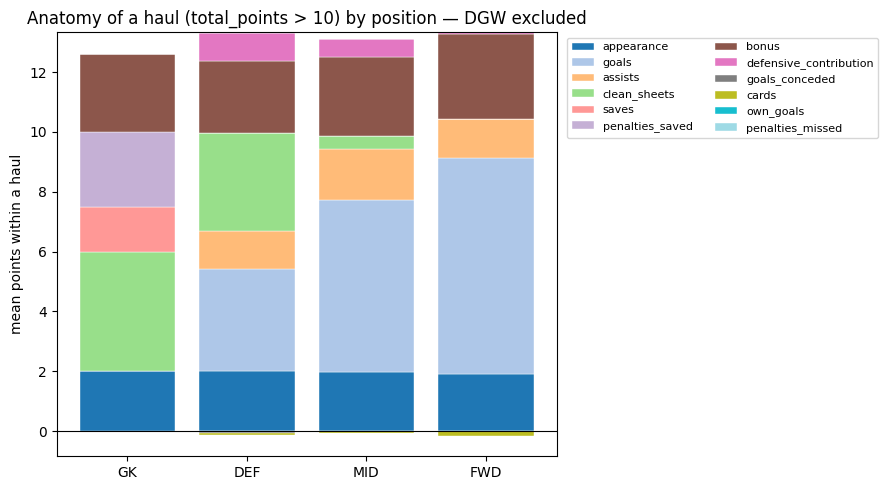

In [2]:
hmeans = components.loc[hauls.index].groupby(hpos).mean().reindex(POSITIONS)[COMP_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(POSITIONS))
bot_pos = np.zeros(len(POSITIONS))
bot_neg = np.zeros(len(POSITIONS))
for c in COMP_ORDER:
    vals = hmeans[c].to_numpy()
    bottoms = np.where(vals >= 0, bot_pos, bot_neg)
    ax.bar(x, vals, bottom=bottoms, color=COLORS[c], label=c, edgecolor="white", linewidth=0.3)
    bot_pos = bot_pos + np.where(vals >= 0, vals, 0.0)
    bot_neg = bot_neg + np.where(vals < 0, vals, 0.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(POSITIONS)
ax.set_ylabel("mean points within a haul")
ax.set_title("Anatomy of a haul (total_points > 10) by position — DGW excluded")
ax.legend(ncol=2, fontsize=8, bbox_to_anchor=(1.01, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

## (b) The haul mix — share by component
> Does the composition of a haul differ across positions?

The positive component means normalised to 100% per position, so the mix is comparable across positions regardless of haul size.

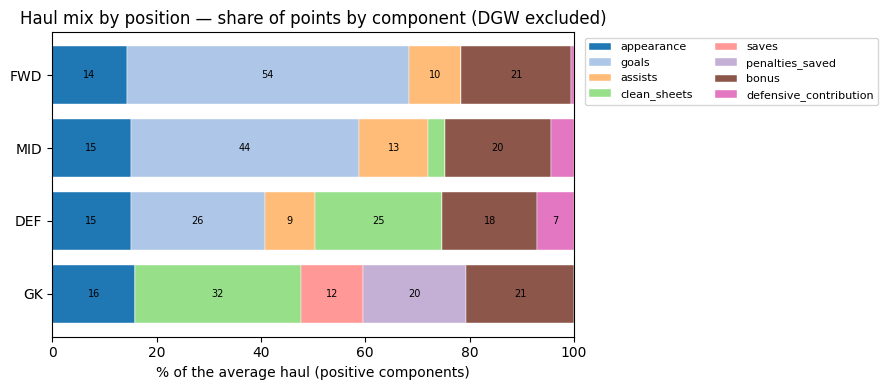

In [3]:
pos_means = hmeans.clip(lower=0)
share = pos_means.div(pos_means.sum(axis=1), axis=0) * 100
keep = [c for c in COMP_ORDER if share[c].max() >= 1.0]
share = share[keep]

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(POSITIONS))
left = np.zeros(len(POSITIONS))
for c in keep:
    vals = share[c].to_numpy()
    ax.barh(y, vals, left=left, color=COLORS[c], label=c, edgecolor="white", linewidth=0.3)
    for yi, (v, lo) in enumerate(zip(vals, left)):
        if v >= 7:
            ax.text(lo + v / 2, yi, f"{v:.0f}", ha="center", va="center", fontsize=7)
    left = left + vals
ax.set_yticks(y); ax.set_yticklabels(POSITIONS)
ax.set_xlabel("% of the average haul (positive components)")
ax.set_title("Haul mix by position — share of points by component (DGW excluded)")
ax.legend(ncol=2, fontsize=8, bbox_to_anchor=(1.01, 1.0), loc="upper left")
plt.tight_layout()
plt.show()